## Analyse Exploratoire (EDA) des données

L'EDA a pour but connaître les données avant de faire quoi que ce soit de sophistiqué. L'objectif est de répondre à des questions simples mais fondamentales sur le dataset GDELT Bénin et d'en tiré les premières statistiques utiles.

## 0. Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    plt.style.use("seaborn-v0_8")
except Exception:
    pass

## 1. Chargement des données

> Le chemin est relatif à la racine du repo.  
> Si l'exécution est sur **Google Colab**, remplacez `DATA_PATH` par le chemin Google Drive.

In [20]:
# Adapter selon votre environnement

# Option A : Local (VS Code, Jupyter classique)
DATA_PATH = Path('..') / 'data' / 'raw' / 'gdelt_bn_2025.csv'

# Option B : Google Colab (décommenter si nécessaire)
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/hackathon/gdelt_bn_2025.csv'


df = pd.read_csv(DATA_PATH, low_memory=False)
# Pour afficher toutes les colonnes
pd.set_option('display.max_columns', None)
print(df.head())

print(f'✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

   GLOBALEVENTID   SQLDATE  MonthYear  Year  FractionDate Actor1Code  \
0     1292975459  20250307     202503  2025     2025.1836        NaN   
1     1289290869  20250215     202502  2025     2025.1233     AFRCVL   
2     1285645948  20250124     202501  2025     2025.0658        HLH   
3     1285645959  20250124     202501  2025     2025.0658        LEG   
4     1285645960  20250124     202501  2025     2025.0658        LEG   

  Actor1Name Actor1CountryCode Actor1KnownGroupCode Actor1EthnicCode  \
0        NaN               NaN                  NaN              NaN   
1     AFRICA               AFR                  NaN              NaN   
2   HOSPITAL               NaN                  NaN              NaN   
3   LAWMAKER               NaN                  NaN              NaN   
4     SENATE               NaN                  NaN              NaN   

  Actor1Religion1Code Actor1Religion2Code Actor1Type1Code Actor1Type2Code  \
0                 NaN                 NaN             NaN

## 2. Structure du dataset

In [8]:
# 2.1 Aperçu général 
print('=' * 60)
print('APERÇU GÉNÉRAL')
print('=' * 60)
print(f"Nombre d'événements  : {df.shape[0]:,}")
print(f"Nombre de colonnes   : {df.shape[1]}")
print(f"Période couverte     : {df['SQLDATE'].min()} → {df['SQLDATE'].max()}")
print(f"Mémoire utilisée     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

APERÇU GÉNÉRAL
Nombre d'événements  : 23,859
Nombre de colonnes   : 61
Période couverte     : 20250101 → 20251231
Mémoire utilisée     : 15.6 MB


In [9]:
# 2.2 Types de colonnes
print('\nTYPES DE COLONNES')
print('-' * 40)
print(df.dtypes.to_string())


TYPES DE COLONNES
----------------------------------------
GLOBALEVENTID              int64
SQLDATE                    int64
MonthYear                  int64
Year                       int64
FractionDate             float64
Actor1Code                   str
Actor1Name                   str
Actor1CountryCode            str
Actor1KnownGroupCode         str
Actor1EthnicCode             str
Actor1Religion1Code          str
Actor1Religion2Code          str
Actor1Type1Code              str
Actor1Type2Code              str
Actor1Type3Code              str
Actor2Code                   str
Actor2Name                   str
Actor2CountryCode            str
Actor2KnownGroupCode         str
Actor2EthnicCode             str
Actor2Religion1Code          str
Actor2Religion2Code          str
Actor2Type1Code              str
Actor2Type2Code              str
Actor2Type3Code              str
IsRootEvent                int64
EventCode                  int64
EventBaseCode              int64
EventRootCode   

In [10]:
# 2.3 Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    '% manquant': missing_pct
}).query('`Valeurs manquantes` > 0').sort_values('% manquant', ascending=False)

print('\nCOLONNES AVEC VALEURS MANQUANTES')
print('-' * 40)
print(missing_df.to_string())



COLONNES AVEC VALEURS MANQUANTES
----------------------------------------
                       Valeurs manquantes  % manquant
Actor2Type3Code                     23853       100.0
Actor1Type3Code                     23843        99.9
Actor2Religion2Code                 23816        99.8
Actor1Religion2Code                 23806        99.8
Actor2EthnicCode                    23775        99.6
Actor1EthnicCode                    23772        99.6
Actor2Religion1Code                 23698        99.3
Actor1Religion1Code                 23679        99.2
Actor2KnownGroupCode                23603        98.9
Actor2Type2Code                     23407        98.1
Actor1KnownGroupCode                23378        98.0
Actor1Type2Code                     23100        96.8
ActionGeo_ADM2Code                  21758        91.2
Actor2Geo_ADM2Code                  21145        88.6
Actor1Geo_ADM2Code                  20309        85.1
Actor2Type1Code                     16012        67.1
Actor2C

## 3. Analyse des colonnes clés GDELT

Selon le codebook GDELT, on se concentre sur les champs pertinents pour le Bénin.


### 3.1 Types d'événements (CAMEO)
Objectif: visualiser les catégories dominantes et la répartition coopération/conflit.
Graphiques: top 10 `EventRootCode` + barres `QuadClass`.


TYPES D'ÉVÉNEMENTS (CAMEO)

Top 10 EventRootCode:
EventRootCode
4     5755
1     3622
5     3128
2     1715
11    1360
19    1310
17    1217
3      979
7      814
8      759
Name: count, dtype: int64



TYPES D'ÉVÉNEMENTS (CAMEO)

Top 10 EventRootCode:
EventRootCode
4     5755
1     3622
5     3128
2     1715
11    1360
19    1310
17    1217
3      979
7      814
8      759
Name: count, dtype: int64


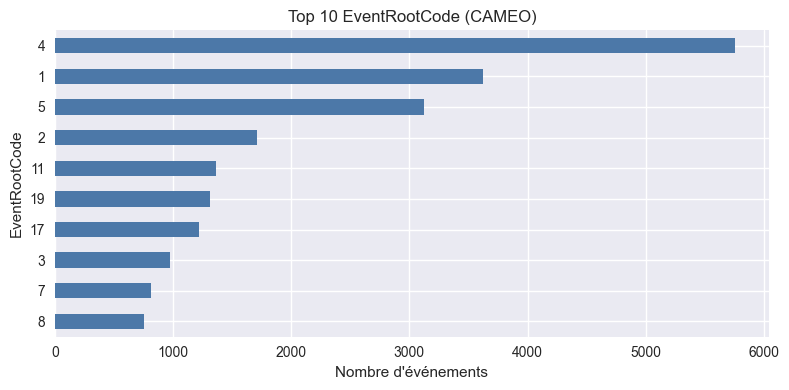


TYPES D'ÉVÉNEMENTS (CAMEO)

Top 10 EventRootCode:
EventRootCode
4     5755
1     3622
5     3128
2     1715
11    1360
19    1310
17    1217
3      979
7      814
8      759
Name: count, dtype: int64


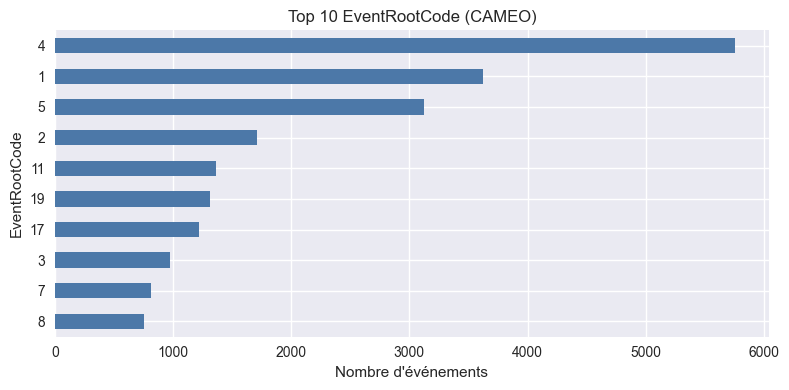


QuadClass (repartition):
                      count   pct
QuadClass                        
Verbal Cooperation    15199  63.7
Material Cooperation   2400  10.1
Verbal Conflict        2888  12.1
Material Conflict      3372  14.1



TYPES D'ÉVÉNEMENTS (CAMEO)

Top 10 EventRootCode:
EventRootCode
4     5755
1     3622
5     3128
2     1715
11    1360
19    1310
17    1217
3      979
7      814
8      759
Name: count, dtype: int64


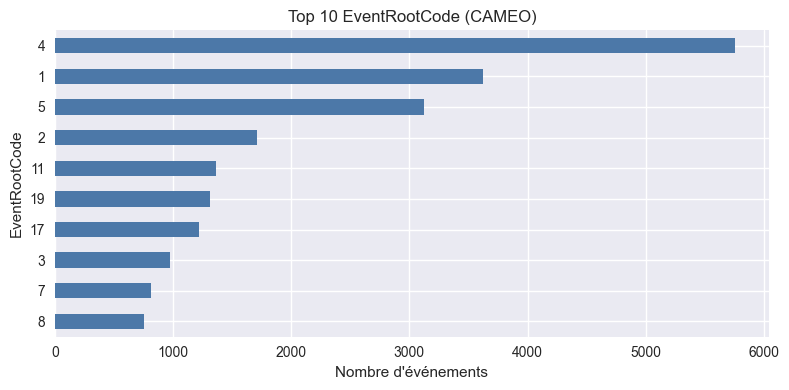


QuadClass (repartition):
                      count   pct
QuadClass                        
Verbal Cooperation    15199  63.7
Material Cooperation   2400  10.1
Verbal Conflict        2888  12.1
Material Conflict      3372  14.1


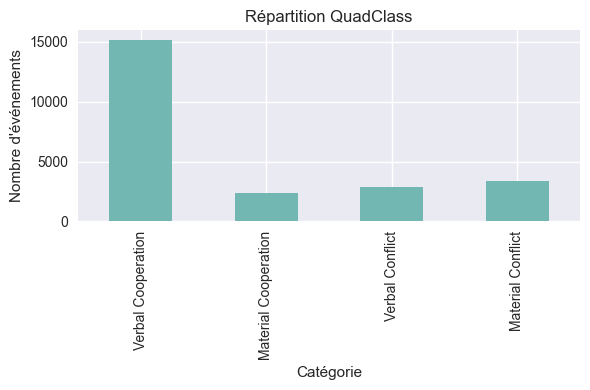

In [11]:
# 3.1 Types d'événements (CAMEO EventCode)
print("\n" + "=" * 60)
print("TYPES D'ÉVÉNEMENTS (CAMEO)")
print("=" * 60)

if "EventRootCode" in df.columns:
    event_root_counts = df["EventRootCode"].value_counts().head(10)
    print("\nTop 10 EventRootCode:")
    print(event_root_counts)

    plot_df = event_root_counts.sort_values()
    ax = plot_df.plot(kind="barh", figsize=(8, 4), color="#4C78A8")
    ax.set_title("Top 10 EventRootCode (CAMEO)")
    ax.set_xlabel("Nombre d'événements")
    ax.set_ylabel("EventRootCode")
    plt.tight_layout()
    plt.show()
else:
    print("Colonne EventRootCode absente.")

if "QuadClass" in df.columns:
    quadclass_map = {
        1: "Verbal Cooperation",
        2: "Material Cooperation",
        3: "Verbal Conflict",
        4: "Material Conflict",
    }
    quad_counts = df["QuadClass"].value_counts().sort_index()
    quad_counts_named = quad_counts.rename(index=quadclass_map)
    quad_table = pd.DataFrame({
        "count": quad_counts_named,
        "pct": (quad_counts_named / len(df) * 100).round(1),
    })
    print("\nQuadClass (repartition):")
    print(quad_table)

    ax = quad_counts_named.plot(kind="bar", figsize=(6, 4), color="#72B7B2")
    ax.set_title("Répartition QuadClass")
    ax.set_xlabel("Catégorie")
    ax.set_ylabel("Nombre d'événements")
    plt.tight_layout()
    plt.show()
else:
    print("Colonne QuadClass absente.")

### 3.2 Acteurs principaux
Objectif: identifier les acteurs les plus fréquents et leurs pays d'affiliation.
Graphiques: top 10 `Actor1Name`, top 10 `Actor2Name`, top 10 `Actor1CountryCode`.


ACTEURS PRINCIPAUX

Top 10 des Actor1 :
Actor1Name
BENIN         5867
NIGERIA       1355
GOVERNMENT     707
POLICE         659
AFRICA         628
GOVERNOR       601
BENIN CITY     406
PRESIDENT      375
ECOWAS         276
MINIST         253
Name: count, dtype: int64



ACTEURS PRINCIPAUX

Top 10 des Actor1 :
Actor1Name
BENIN         5867
NIGERIA       1355
GOVERNMENT     707
POLICE         659
AFRICA         628
GOVERNOR       601
BENIN CITY     406
PRESIDENT      375
ECOWAS         276
MINIST         253
Name: count, dtype: int64


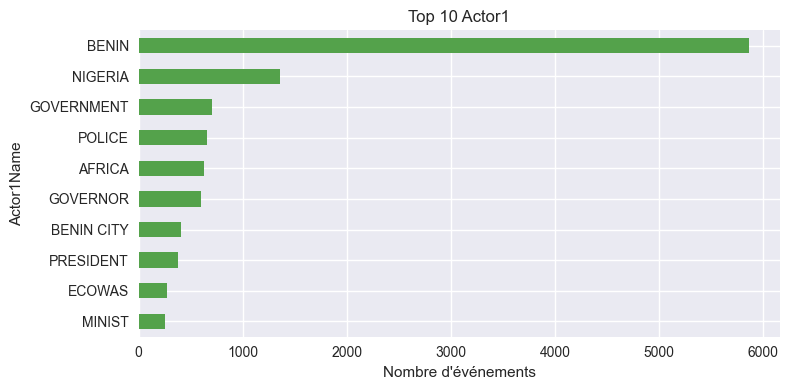


ACTEURS PRINCIPAUX

Top 10 des Actor1 :
Actor1Name
BENIN         5867
NIGERIA       1355
GOVERNMENT     707
POLICE         659
AFRICA         628
GOVERNOR       601
BENIN CITY     406
PRESIDENT      375
ECOWAS         276
MINIST         253
Name: count, dtype: int64


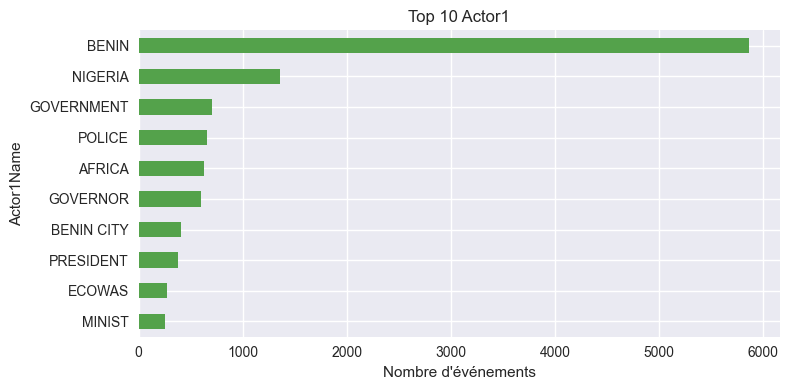



Top 10 des Actor2 :
Actor2Name
BENIN         4637
NIGERIA       1053
GOVERNMENT     612
AFRICA         571
BENIN CITY     509
GOVERNOR       380
PRESIDENT      288
POLICE         251
MILITARY       228
COTONOU        227
Name: count, dtype: int64



ACTEURS PRINCIPAUX

Top 10 des Actor1 :
Actor1Name
BENIN         5867
NIGERIA       1355
GOVERNMENT     707
POLICE         659
AFRICA         628
GOVERNOR       601
BENIN CITY     406
PRESIDENT      375
ECOWAS         276
MINIST         253
Name: count, dtype: int64


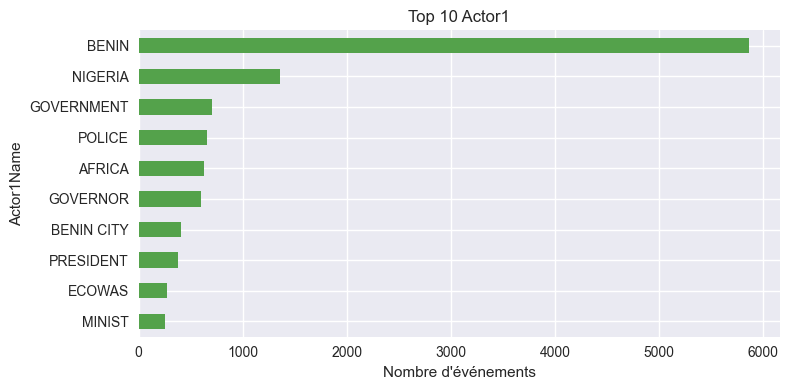



Top 10 des Actor2 :
Actor2Name
BENIN         4637
NIGERIA       1053
GOVERNMENT     612
AFRICA         571
BENIN CITY     509
GOVERNOR       380
PRESIDENT      288
POLICE         251
MILITARY       228
COTONOU        227
Name: count, dtype: int64


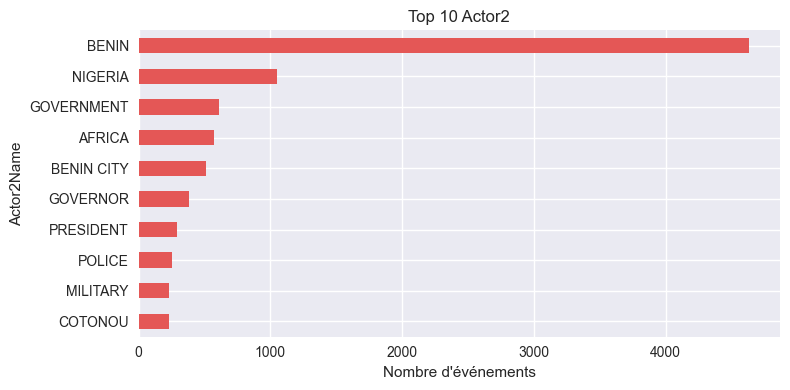


ACTEURS PRINCIPAUX

Top 10 des Actor1 :
Actor1Name
BENIN         5867
NIGERIA       1355
GOVERNMENT     707
POLICE         659
AFRICA         628
GOVERNOR       601
BENIN CITY     406
PRESIDENT      375
ECOWAS         276
MINIST         253
Name: count, dtype: int64


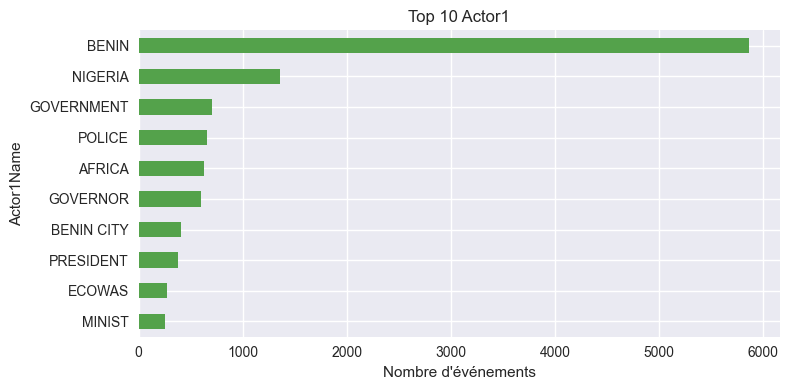



Top 10 des Actor2 :
Actor2Name
BENIN         4637
NIGERIA       1053
GOVERNMENT     612
AFRICA         571
BENIN CITY     509
GOVERNOR       380
PRESIDENT      288
POLICE         251
MILITARY       228
COTONOU        227
Name: count, dtype: int64


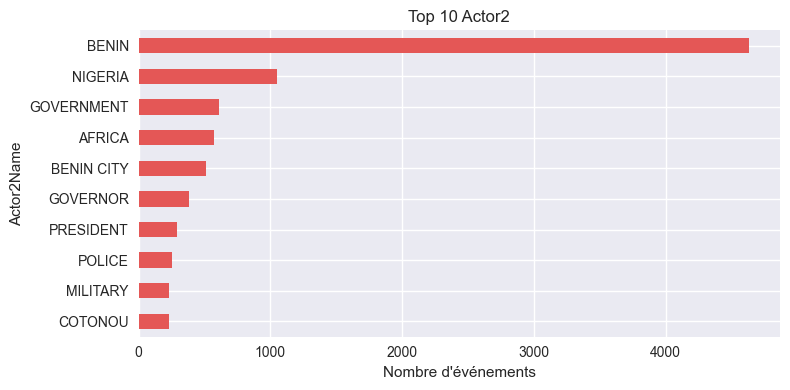



Codes pays Actor1 (Top 10):
Actor1CountryCode
BEN    6353
NGA    2198
AFR     694
FRA     335
WAF     331
USA     198
NER     197
GBR     135
GHA     128
TGO     121
Name: count, dtype: int64



ACTEURS PRINCIPAUX

Top 10 des Actor1 :
Actor1Name
BENIN         5867
NIGERIA       1355
GOVERNMENT     707
POLICE         659
AFRICA         628
GOVERNOR       601
BENIN CITY     406
PRESIDENT      375
ECOWAS         276
MINIST         253
Name: count, dtype: int64


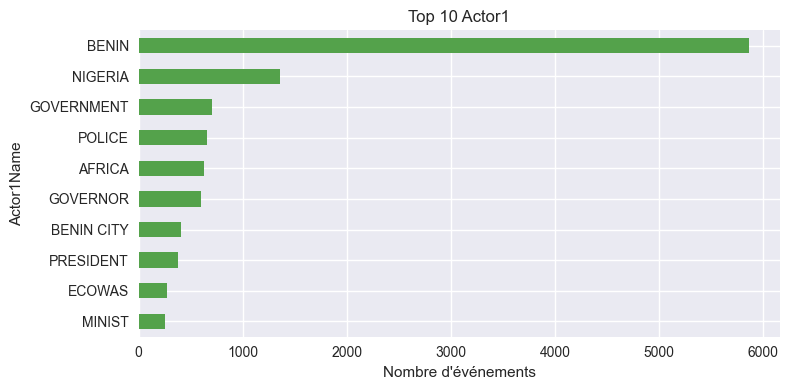



Top 10 des Actor2 :
Actor2Name
BENIN         4637
NIGERIA       1053
GOVERNMENT     612
AFRICA         571
BENIN CITY     509
GOVERNOR       380
PRESIDENT      288
POLICE         251
MILITARY       228
COTONOU        227
Name: count, dtype: int64


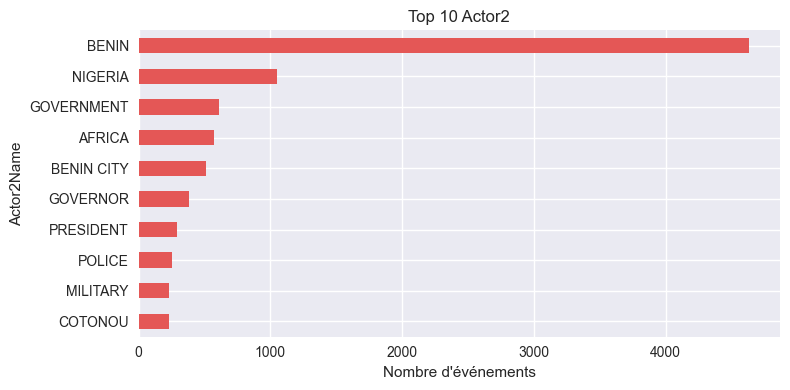



Codes pays Actor1 (Top 10):
Actor1CountryCode
BEN    6353
NGA    2198
AFR     694
FRA     335
WAF     331
USA     198
NER     197
GBR     135
GHA     128
TGO     121
Name: count, dtype: int64


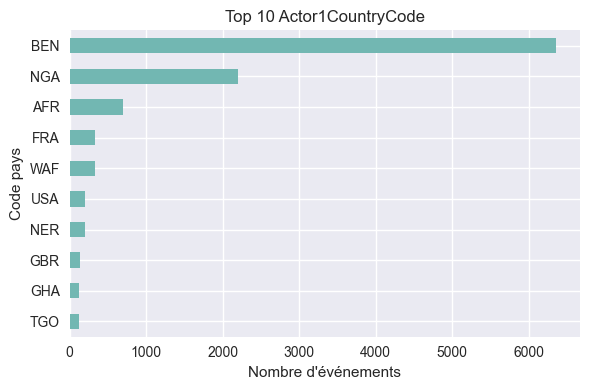

In [12]:
# 3.2 Acteurs principaux (Actor1 et Actor2)
print("\n" + "=" * 60)
print("ACTEURS PRINCIPAUX")
print("=" * 60)

if "Actor1Name" in df.columns:
    actor1_counts = df["Actor1Name"].dropna().value_counts().head(10)
    print("\nTop 10 des Actor1 :")
    print(actor1_counts)

    plot_df = actor1_counts.sort_values()
    ax = plot_df.plot(kind="barh", figsize=(8, 4), color="#54A24B")
    ax.set_title("Top 10 Actor1")
    ax.set_xlabel("Nombre d'événements")
    ax.set_ylabel("Actor1Name")
    plt.tight_layout()
    plt.show()
else:
    print("Colonne Actor1Name absente.")

if "Actor2Name" in df.columns:
    actor2_counts = df["Actor2Name"].dropna().value_counts().head(10)
    print("\n\nTop 10 des Actor2 :")
    print(actor2_counts)

    plot_df = actor2_counts.sort_values()
    ax = plot_df.plot(kind="barh", figsize=(8, 4), color="#E45756")
    ax.set_title("Top 10 Actor2")
    ax.set_xlabel("Nombre d'événements")
    ax.set_ylabel("Actor2Name")
    plt.tight_layout()
    plt.show()
else:
    print("Colonne Actor2Name absente.")

if "Actor1CountryCode" in df.columns:
    country_counts = df["Actor1CountryCode"].dropna().value_counts().head(10)
    print("\n\nCodes pays Actor1 (Top 10):")
    print(country_counts)

    plot_df = country_counts.sort_values()
    ax = plot_df.plot(kind="barh", figsize=(6, 4), color="#72B7B2")
    ax.set_title("Top 10 Actor1CountryCode")
    ax.set_xlabel("Nombre d'événements")
    ax.set_ylabel("Code pays")
    plt.tight_layout()
    plt.show()
else:
    print("Colonne Actor1CountryCode absente.")

### 3.3 Localisation des événements
Objectif: comprendre où les événements se produisent et la précision géographique.
Graphiques: top 10 `ActionGeo_Fullname`, répartition `ActionGeo_Type`, nuage lat/long (échantillon).


LOCALISATION GÉOGRAPHIQUE (ActionGeo_*)
Colonne ActionGeo_Fullname absente.

Codes pays du lieu d'action (Top 10) :
ActionGeo_CountryCode
BN    23859
Name: count, dtype: int64



LOCALISATION GÉOGRAPHIQUE (ActionGeo_*)
Colonne ActionGeo_Fullname absente.

Codes pays du lieu d'action (Top 10) :
ActionGeo_CountryCode
BN    23859
Name: count, dtype: int64


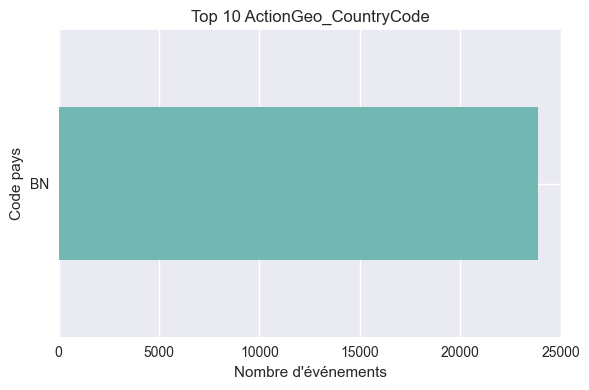


LOCALISATION GÉOGRAPHIQUE (ActionGeo_*)
Colonne ActionGeo_Fullname absente.

Codes pays du lieu d'action (Top 10) :
ActionGeo_CountryCode
BN    23859
Name: count, dtype: int64


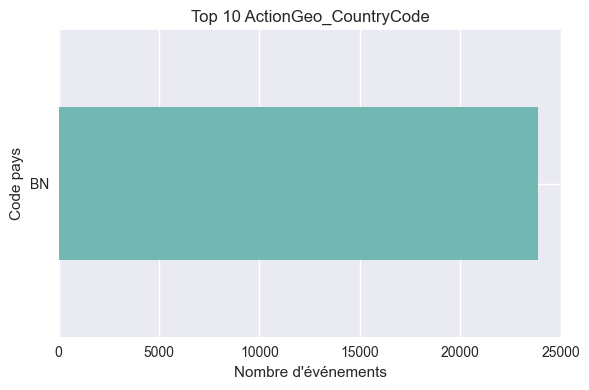


Précision géographique (ActionGeo_Type):
ActionGeo_Type
COUNTRY       21758
WORLDCITY      1890
WORLDSTATE      211
Name: count, dtype: int64



LOCALISATION GÉOGRAPHIQUE (ActionGeo_*)
Colonne ActionGeo_Fullname absente.

Codes pays du lieu d'action (Top 10) :
ActionGeo_CountryCode
BN    23859
Name: count, dtype: int64


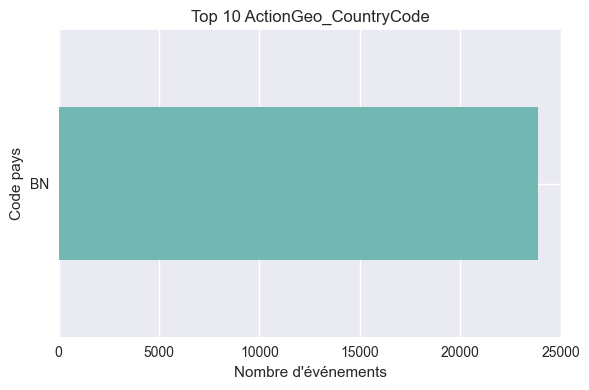


Précision géographique (ActionGeo_Type):
ActionGeo_Type
COUNTRY       21758
WORLDCITY      1890
WORLDSTATE      211
Name: count, dtype: int64


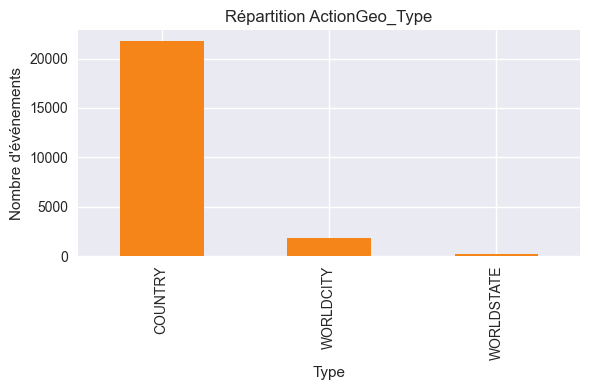


LOCALISATION GÉOGRAPHIQUE (ActionGeo_*)
Colonne ActionGeo_Fullname absente.

Codes pays du lieu d'action (Top 10) :
ActionGeo_CountryCode
BN    23859
Name: count, dtype: int64


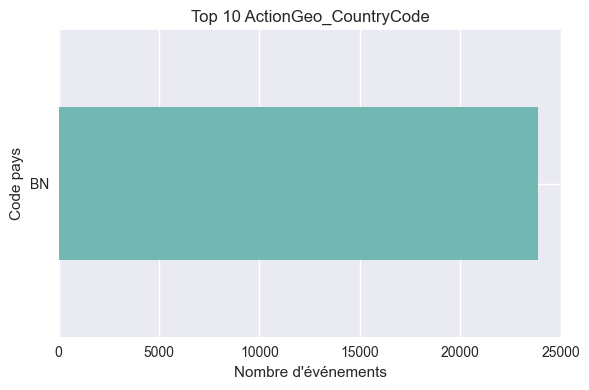


Précision géographique (ActionGeo_Type):
ActionGeo_Type
COUNTRY       21758
WORLDCITY      1890
WORLDSTATE      211
Name: count, dtype: int64


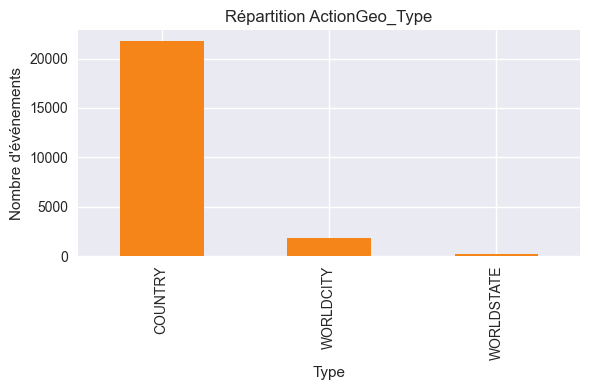

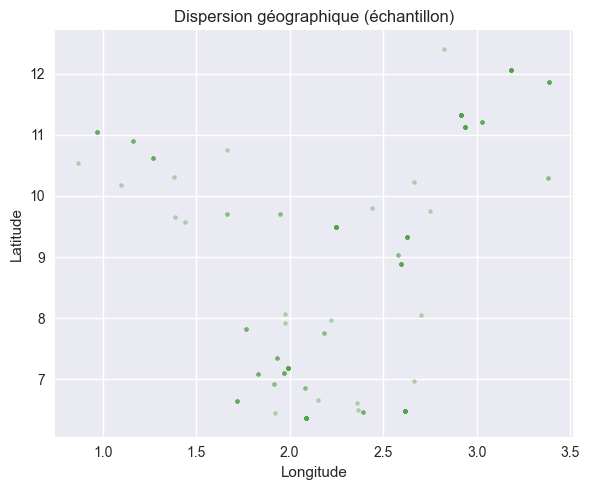

In [13]:
# 3.3 Localisation géographique des événements
print("\n" + "=" * 60)
print("LOCALISATION GÉOGRAPHIQUE (ActionGeo_*)")
print("=" * 60)

if "ActionGeo_Fullname" in df.columns:
    place_counts = df["ActionGeo_Fullname"].dropna().value_counts().head(10)
    print("\nLieux d'action (Top 10) :")
    print(place_counts)

    plot_df = place_counts.sort_values()
    ax = plot_df.plot(kind="barh", figsize=(8, 4), color="#4C78A8")
    ax.set_title("Top 10 ActionGeo_Fullname")
    ax.set_xlabel("Nombre d'événements")
    ax.set_ylabel("Lieu")
    plt.tight_layout()
    plt.show()
else:
    print("Colonne ActionGeo_Fullname absente.")

if "ActionGeo_CountryCode" in df.columns:
    country_counts = df["ActionGeo_CountryCode"].dropna().value_counts().head(10)
    print("\nCodes pays du lieu d'action (Top 10) :")
    print(country_counts)

    plot_df = country_counts.sort_values()
    ax = plot_df.plot(kind="barh", figsize=(6, 4), color="#72B7B2")
    ax.set_title("Top 10 ActionGeo_CountryCode")
    ax.set_xlabel("Nombre d'événements")
    ax.set_ylabel("Code pays")
    plt.tight_layout()
    plt.show()
else:
    print("Colonne ActionGeo_CountryCode absente.")

if "ActionGeo_Type" in df.columns:
    geo_type_map = {
        1: "COUNTRY",
        2: "USSTATE",
        3: "USCITY",
        4: "WORLDCITY",
        5: "WORLDSTATE",
    }
    geo_type_counts = df["ActionGeo_Type"].value_counts().sort_index()
    geo_type_named = geo_type_counts.rename(index=geo_type_map)
    print("\nPrécision géographique (ActionGeo_Type):")
    print(geo_type_named)

    ax = geo_type_named.plot(kind="bar", figsize=(6, 4), color="#F58518")
    ax.set_title("Répartition ActionGeo_Type")
    ax.set_xlabel("Type")
    ax.set_ylabel("Nombre d'événements")
    plt.tight_layout()
    plt.show()
else:
    print("Colonne ActionGeo_Type absente.")

if "ActionGeo_Lat" in df.columns and "ActionGeo_Long" in df.columns:
    geo_sample = df[["ActionGeo_Lat", "ActionGeo_Long"]].dropna()
    if not geo_sample.empty:
        geo_sample = geo_sample.sample(n=min(2000, len(geo_sample)), random_state=42)
        plt.figure(figsize=(6, 5))
        plt.scatter(
            geo_sample["ActionGeo_Long"],
            geo_sample["ActionGeo_Lat"],
            s=8,
            alpha=0.4,
            color="#54A24B",
        )
        plt.title("Dispersion géographique (échantillon)")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.tight_layout()
        plt.show()

### 3.4 Importance et couverture médias
Objectif: mesurer l'attention médiatique (longue traîne).
Graphiques: distributions en log1p de `NumMentions`, `NumSources`, `NumArticles`.


IMPORTANCE ET COUVERTURE MÉDIAS

NumMentions :
  Min: 1
  Max: 48
  Médiane: 5.0
  Moyenne: 5.9

NumSources :
  Min: 1
  Max: 7
  Médiane: 1.0
  Moyenne: 1.0

NumArticles :
  Min: 1
  Max: 48
  Médiane: 5.0
  Moyenne: 5.8



IMPORTANCE ET COUVERTURE MÉDIAS

NumMentions :
  Min: 1
  Max: 48
  Médiane: 5.0
  Moyenne: 5.9

NumSources :
  Min: 1
  Max: 7
  Médiane: 1.0
  Moyenne: 1.0

NumArticles :
  Min: 1
  Max: 48
  Médiane: 5.0
  Moyenne: 5.8


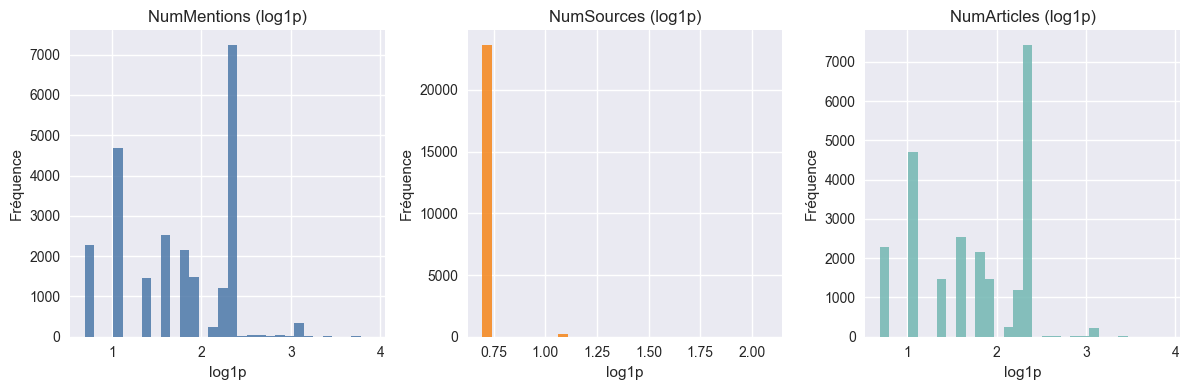

In [14]:
# 3.4 Importance des événements (media attention)
print("\n" + "=" * 60)
print("IMPORTANCE ET COUVERTURE MÉDIAS")
print("=" * 60)

metrics = ["NumMentions", "NumSources", "NumArticles"]
for col in metrics:
    if col in df.columns:
        series = df[col].dropna()
        print(f"\n{col} :")
        print(f"  Min: {series.min()}")
        print(f"  Max: {series.max()}")
        print(f"  Médiane: {series.median()}")
        print(f"  Moyenne: {series.mean():.1f}")
    else:
        print(f"\n{col} : colonne absente.")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ["#4C78A8", "#F58518", "#72B7B2"]

for ax, col, color in zip(axes, metrics, colors):
    if col in df.columns:
        series = df[col].dropna()
        ax.hist(np.log1p(series), bins=30, color=color, alpha=0.85)
        ax.set_title(f"{col} (log1p)")
        ax.set_xlabel("log1p")
        ax.set_ylabel("Fréquence")
    else:
        ax.text(0.5, 0.5, f"{col}\nabsente", ha="center", va="center")
        ax.set_axis_off()

plt.tight_layout()
plt.show()

### 3.5 Sentiment et impact
Objectif: voir la tonalité (AvgTone) et l'impact théorique (GoldsteinScale).
Graphiques: histogrammes avec repère 0.


SENTIMENT ET IMPACT

AvgTone (sentiment):
  Min: -18.5185185185185
  Max: 19.4805194805195
  Médiane: -1.37
  Moyenne: -1.49

GoldsteinScale (impact théorique):
  Min: -10.0
  Max: 10.0
  Médiane: 1.9
  Moyenne: 0.55



SENTIMENT ET IMPACT

AvgTone (sentiment):
  Min: -18.5185185185185
  Max: 19.4805194805195
  Médiane: -1.37
  Moyenne: -1.49

GoldsteinScale (impact théorique):
  Min: -10.0
  Max: 10.0
  Médiane: 1.9
  Moyenne: 0.55


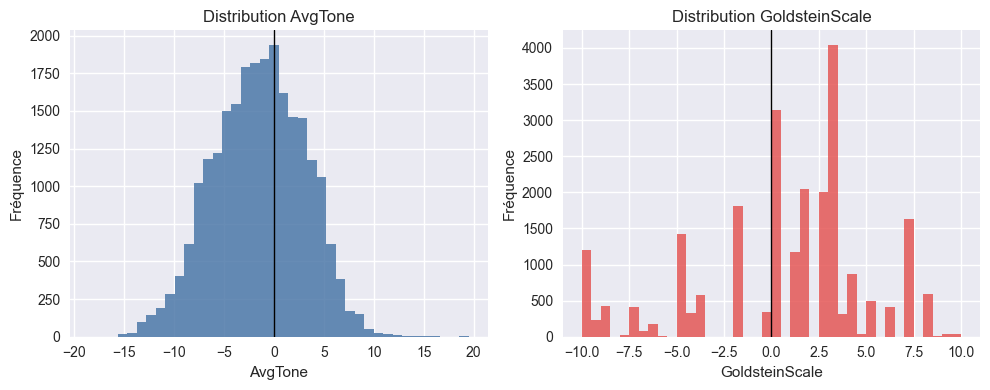

In [15]:
# 3.5 Sentiment et Goldstein Scale
print("\n" + "=" * 60)
print("SENTIMENT ET IMPACT")
print("=" * 60)

if "AvgTone" in df.columns:
    tone = df["AvgTone"].dropna()
    print("\nAvgTone (sentiment):")
    print(f"  Min: {tone.min()}")
    print(f"  Max: {tone.max()}")
    print(f"  Médiane: {tone.median():.2f}")
    print(f"  Moyenne: {tone.mean():.2f}")
else:
    print("\nAvgTone : colonne absente.")

if "GoldsteinScale" in df.columns:
    gold = df["GoldsteinScale"].dropna()
    print("\nGoldsteinScale (impact théorique):")
    print(f"  Min: {gold.min()}")
    print(f"  Max: {gold.max()}")
    print(f"  Médiane: {gold.median():.1f}")
    print(f"  Moyenne: {gold.mean():.2f}")
else:
    print("\nGoldsteinScale : colonne absente.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

if "AvgTone" in df.columns:
    axes[0].hist(tone, bins=40, color="#4C78A8", alpha=0.85)
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set_title("Distribution AvgTone")
    axes[0].set_xlabel("AvgTone")
    axes[0].set_ylabel("Fréquence")
else:
    axes[0].text(0.5, 0.5, "AvgTone\nabsente", ha="center", va="center")
    axes[0].set_axis_off()

if "GoldsteinScale" in df.columns:
    axes[1].hist(gold, bins=40, color="#E45756", alpha=0.85)
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_title("Distribution GoldsteinScale")
    axes[1].set_xlabel("GoldsteinScale")
    axes[1].set_ylabel("Fréquence")
else:
    axes[1].text(0.5, 0.5, "GoldsteinScale\nabsente", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

### 3.6 Dynamique temporelle
Objectif: voir la saisonnalité mensuelle et la répartition par jour de semaine.
Graphiques: courbe mensuelle + barres par jour.


TIMELINE

Événements par mois :
EventDate
2025-01    2163
2025-02    1673
2025-03    2067
2025-04    2125
2025-05    1807
2025-06     908
2025-07    2284
2025-08    1516
2025-09    1630
2025-10    1676
2025-11    1789
2025-12    4221
Freq: M, Name: count, dtype: int64



TIMELINE

Événements par mois :
EventDate
2025-01    2163
2025-02    1673
2025-03    2067
2025-04    2125
2025-05    1807
2025-06     908
2025-07    2284
2025-08    1516
2025-09    1630
2025-10    1676
2025-11    1789
2025-12    4221
Freq: M, Name: count, dtype: int64


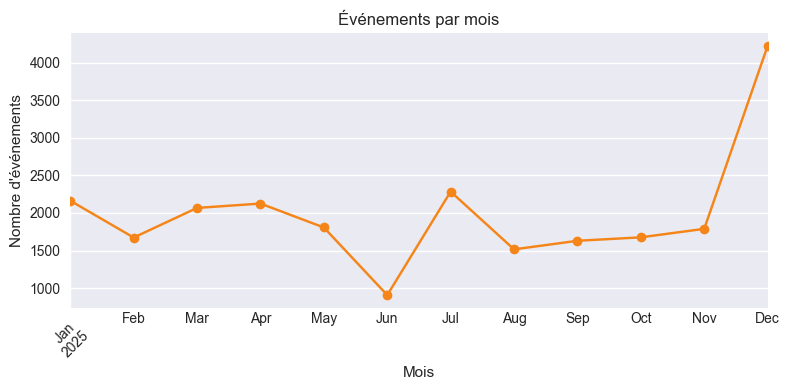


TIMELINE

Événements par mois :
EventDate
2025-01    2163
2025-02    1673
2025-03    2067
2025-04    2125
2025-05    1807
2025-06     908
2025-07    2284
2025-08    1516
2025-09    1630
2025-10    1676
2025-11    1789
2025-12    4221
Freq: M, Name: count, dtype: int64


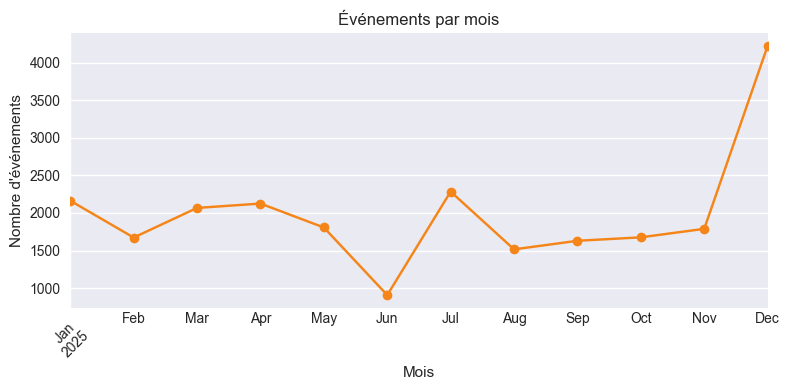


Événements par jour de la semaine :
EventDate
Monday       3890
Tuesday      3652
Wednesday    3883
Thursday     3762
Friday       3639
Saturday     2232
Sunday       2801
Name: count, dtype: int64



TIMELINE

Événements par mois :
EventDate
2025-01    2163
2025-02    1673
2025-03    2067
2025-04    2125
2025-05    1807
2025-06     908
2025-07    2284
2025-08    1516
2025-09    1630
2025-10    1676
2025-11    1789
2025-12    4221
Freq: M, Name: count, dtype: int64


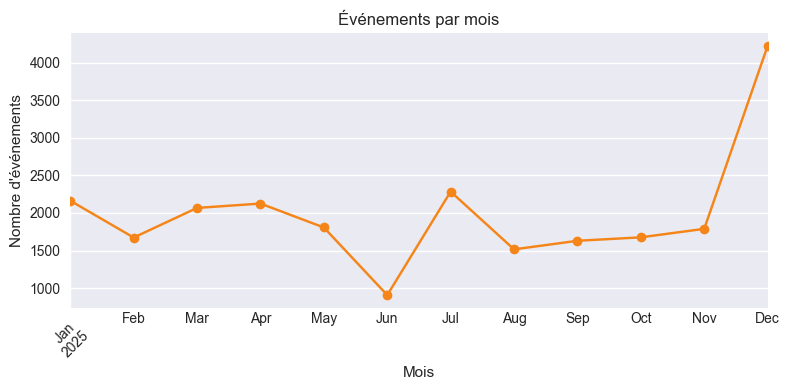


Événements par jour de la semaine :
EventDate
Monday       3890
Tuesday      3652
Wednesday    3883
Thursday     3762
Friday       3639
Saturday     2232
Sunday       2801
Name: count, dtype: int64


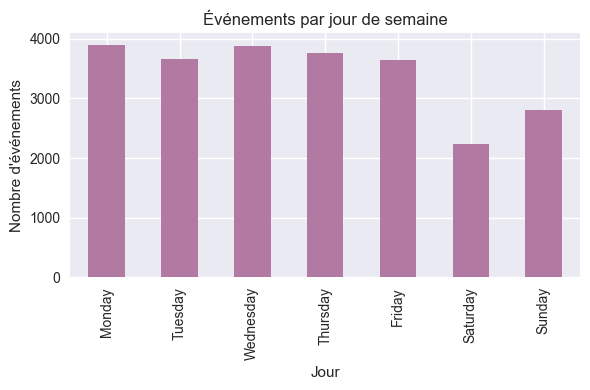

In [16]:
# 3.6 Timeline des événements
print("\n" + "=" * 60)
print("TIMELINE")
print("=" * 60)

if "SQLDATE" in df.columns:
    df["EventDate"] = pd.to_datetime(df["SQLDATE"], format="%Y%m%d", errors="coerce")

    monthly_counts = df["EventDate"].dt.to_period("M").value_counts().sort_index()
    print("\nÉvénements par mois :")
    print(monthly_counts)

    ax = monthly_counts.plot(kind="line", marker="o", figsize=(8, 4), color="#F58518")
    ax.set_title("Événements par mois")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Nombre d'événements")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_counts = df["EventDate"].dt.day_name().value_counts().reindex(day_order)
    print("\nÉvénements par jour de la semaine :")
    print(dow_counts)

    ax = dow_counts.plot(kind="bar", figsize=(6, 4), color="#B279A2")
    ax.set_title("Événements par jour de semaine")
    ax.set_xlabel("Jour")
    ax.set_ylabel("Nombre d'événements")
    plt.tight_layout()
    plt.show()
else:
    print("Colonne SQLDATE absente.")